# OLX Ko'chmas mulk — Malumot Tozalash jaroyoni  
Kodni tepadan paga qarab yurg'azing. Oxirida sizda tayor `cleaned.csv` fileli modeling uchun tayor bo'ladi.

In [250]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

In [251]:
df = pd.read_csv('../data/Praperad/olx_apartments.csv')
print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')

Loaded: 75,717 rows, 29 columns


In [252]:
df.isna().sum()

listing_id             0
source                 0
seller_type            1
housing_type       26162
region                 1
district               1
rooms                  1
living_area_m2     50555
kitchen_area_m2    58003
total_area_m2         11
floor                  3
total_floors           1
building_type      18937
layout             27112
build_year         52839
ceiling_height     48361
bathroom           21272
furnished              5
renovation         14291
commission             1
amenities          27904
nearby             24836
negotiable             0
price                195
currency               0
published_date         1
description            1
date_scraped           0
url                    0
dtype: int64

In [253]:
df.head()

,listing_id,source,seller_type,housing_type,region,district,rooms,living_area_m2,kitchen_area_m2,total_area_m2,...,commission,amenities,nearby,negotiable,price,currency,published_date,description,date_scraped,url
0,4jYx9,olx,private,resale,Tashkent Region,Chilanzar District,1.0,20.0,6.0,29.0,...,0.0,"Internet, Refrigerator, TV, Air Conditioning, ...","Hospital, Clinic, Playground, Kindergarten, Bu...",1,60000.0,USD,01/05/2026,Описание Уй локацияси зур жойда жойлашган. Мир...,2026-05-02,https://www.olx.uz/d/obyavlenie/1-hona-metro-o...
1,4myoT,olx,private,NaN,Tashkent Region,Yunusabad District,2.0,80.0,NaN,80.0,...,1.0,"Internet, Refrigerator, TV, Air Conditioning, ...","Hospital, Clinic, Playground, Kindergarten, Bu...",0,7865000.0,UZS,30/04/2026,Описание Сдается в аренду 2/6/13 Юнусабад 13 к...,2026-05-02,https://www.olx.uz/d/obyavlenie/sdaetsya-v-are...
2,4lvjL,olx,business,new building,Tashkent Region,Yunusabad District,3.0,NaN,NaN,80.0,...,0.0,"Internet, Refrigerator, TV, Air Conditioning, ...","Hospital, Clinic, School, Playground, Kinderga...",0,220000.0,USD,29/04/2026,Описание Продается квартира !!! 3/6/9 80 кВ По...,2026-05-02,https://www.olx.uz/d/obyavlenie/srochno-prodae...
3,4aiOy,olx,private,NaN,Tashkent Region,Shaykhantakhur District,3.0,67.5,NaN,67.5,...,0.0,"Internet, Refrigerator, TV, Air Conditioning, ...",NaN,0,1400.0,USD,02/05/2026,"Описание Квартира в новостройке Tashkent City,...",2026-05-02,https://www.olx.uz/d/obyavlenie/sdaetsya-v-are...
4,4mAGS,olx,business,resale,Tashkent Region,Yashnabad District,3.0,50.0,NaN,78.0,...,1.0,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, Playground, Kindergarten, Bu...",0,120000.0,USD,02/05/2026,Описание Продается своя квартира 3/1/4 Кирпичн...,2026-05-02,https://www.olx.uz/d/obyavlenie/kvartira-3-1-4...


## A. Malumotna uchun shartnoma

# Ma'lumotlar lug'ati — OLX.uz kvartiralar dataseti
 
> **Hajmi:** 18 000+ qator × 28 ustun  
> **Manba:** OLX.uz — kvartiralar bo'limi (`/nedvizhimost/kvartiry/`)  
> **Skraping sanasi:** 2026-04-15 - hozir

## B. Ma'lumotlarni qabul qilish va dastlabki tekshiruvlar

### B.1. Asosiy qabul qilish ro'yxati:

In [254]:
print(f'File nomi: olx_apartments.csv')
print(f'Qatorlar soni: {df.shape[0]}')
print(f'Ustunlar soni: {df.shape[1]}')
print(f"Ustun nomlari malumot ustuniga o'xshashmimi: (Ha/yoq): Ha")

File nomi: olx_apartments.csv
Qatorlar soni: 75717
Ustunlar soni: 29
Ustun nomlari malumot ustuniga o'xshashmimi: (Ha/yoq): Ha


### B.2. Noyoblik + dublikatlar (Dunyo talabi)

In [255]:
before = len(df)
after = df.duplicated().sum()
print(f"Dublikatlar soni: {after}")
print(f'Noyoblik soni: {before-after}')
df_cleaned = df.drop_duplicates()

Dublikatlar soni: 3269
Noyoblik soni: 72448


### B.3. Natija yaxlitligini tekshirish
  
>Faqatgina ko'zlangan malumonni o'z ichaga oladimi? (yani narxni)  
* 2 hil turdaki valyuta aralashgan UZB va USD.
>Biror yoqolgan qiymatlar bormi?
* Bor 50 rotiq
>G‘alati yozilgan (imlosi noto‘g‘ri) so‘zlar bormi?
* Hozircha kuzatilmadi

## C. Malumot sifati (Nima hato ekanligini isbotlash)
  
### C.1. Yetishmayotgan Qiymatlar Profili
 
**Dataset hajmi:** 18,267 qator (`price` ustunidagi 40 ta bo'sh qiymat o'chirilgandan keyin)
 
---
 
## Yetishmayotgan Qiymatlar Jadvali
 
| Ustun | Yetishmaydi (n) | % | Qabul qilinadimi? | Nega yetishmayotgan bo'lishi mumkin? |
|---|---|---|---|---|
| listing_id | 0 | 0.0% | ✅ Ha | — |
| seller_type | 1 | 0.0% | ✅ Ha | Kichik ma'lumot kiritish xatosi |
| housing_type | 5,956 | 32.6% | ⚠️ Balki | Forma to'ldirishda majburiy emas |
| region | 1 | 0.0% | ✅ Ha | Kichik ma'lumot kiritish xatosi |
| district | 1 | 0.0% | ✅ Ha | Kichik ma'lumot kiritish xatosi |
| rooms | 1 | 0.0% | ✅ Ha | Kichik ma'lumot kiritish xatosi |
| living_area_m2 | 12,862 | 70.4% | ❌ Yo'q | Sotuvchilar ko'pincha maydon ma'lumotini qoldirmaydi |
| kitchen_area_m2 | 14,775 | 80.9% | ❌ Yo'q | Alohida ko'rsatilmaydi; ixtiyoriy maydon |
| total_area_m2 | 4 | 0.0% | ✅ Ha | Deyarli to'liq |
| floor | 2 | 0.0% | ✅ Ha | Deyarli to'liq |
| total_floors | 1 | 0.0% | ✅ Ha | Deyarli to'liq |
| building_type | 4,488 | 24.6% | ⚠️ Balki | Sotuvchi har doim bilmasligi mumkin |
| layout | 6,378 | 34.9% | ⚠️ Balki | Ixtiyoriy maydon; subyektiv tasnif |
| build_year | 13,785 | 75.5% | ❌ Yo'q | Eski binolarda hujjat yo'q bo'lishi mumkin |
| ceiling_height | 12,486 | 68.4% | ❌ Yo'q | E'lonlarda kamdan-kam ko'rsatiladi |
| bathroom | 5,057 | 27.7% | ⚠️ Balki | Ko'p formatlarda ixtiyoriy |
| furnished | 3 | 0.0% | ✅ Ha | Deyarli to'liq |
| renovation | 3,370 | 18.4% | ⚠️ Balki | Sotuvchi ta'mirlash holatini ko'rsatmasligi mumkin |
| commission | 1 | 0.0% | ✅ Ha | Deyarli to'liq |
| amenities | 7,045 | 38.6% | ⚠️ Balki | Ixtiyoriy maydon; har doim to'ldirilmaydi |
| nearby | 6,523 | 35.7% | ⚠️ Balki | Ixtiyoriy qo'shimcha maydon |
| negotiable | 0 | 0.0% | ✅ Ha | — |
| price | 40 | 0.2% | ❌ Yo'q | Maqsad ustun — to'liq bo'lishi shart; o'chirildi |
| currency | 0 | 0.0% | ✅ Ha | — |
| published_date | 1 | 0.0% | ✅ Ha | Kichik ma'lumot kiritish xatosi |
| description | 1 | 0.0% | ✅ Ha | Deyarli to'liq |
| date_scraped | 0 | 0.0% | ✅ Ha | — |
| url | 0 | 0.0% | ✅ Ha | — |
 
---
 
## Yetishmayotgan Qiymatlar Tahlili
 
### Yetishmayotgan qiymatlar tasodifiy yoki tizimliymi?
 
Bu datasetdagi yetishmayotgan qiymatlar **to'liq tasodifiy emas**. `living_area_m2` (70.4%), `kitchen_area_m2` (80.9%), `build_year` (75.5%) va `ceiling_height` (68.4%) ustunlarida qiymatlarning aksariyati yo'q. Bu **tizimli muammo**ni ko'rsatadi: ushbu maydonlar platforma formasida ixtiyoriy bo'lgan yoki sotuvchilar ularni to'ldirishni istamagan.
 
### Yetishmayotgan qiymatlar narx (price) bilan bog'liqmi?
 
Jismoniy xususiyatlari (maydon, qurilish yili, shift balandligi) ko'rsatilmagan e'lonlar **past sifatli yoki norasmiy** bo'lishi mumkin, bu esa narxlarning ham past bo'lishiga olib keladi. Agar shunday bo'lsa, bu ustunlarni o'rtacha qiymat bilan to'ldirish (imputation) **narx bashoratlarini yuqori tomonga siljitishi** mumkin.
 
### Guruhlar bo'yicha yetishmayotgan % ni tekshirish (tavsiya)
 
```python
# housing_type bo'yicha yetishmayotgan %
df.groupby('housing_type').apply(lambda x: x.isnull().mean() * 100)
 
# region bo'yicha yetishmayotgan %
df.groupby('region').apply(lambda x: x.isnull().mean() * 100)
```
 
### Xulosa
 
Yetishmayotgan qiymatlar **qisman tizimli** xarakterga ega: `living_area_m2`, `kitchen_area_m2`, `build_year` va `ceiling_height` ustunlarida 68–81% qiymat yo'q, chunki platforma ularni ixtiyoriy maydon sifatida ko'rsatadi. Bu oddiy xato emas — bu sotuvchilarning e'lon to'ldirishdagi tarkibiy kamchiligidir. Modellashtirish oldidan ushbu ustunlar uchun qaror qabul qilish kerak: **ustunlarni o'chirish**, **ehtiyotkorlik bilan to'ldirish (imputation)**, yoki **yetishmayotganlikni alohida belgi (binary flag) sifatida saqlash**.

### Amal qiladigan oralag'i columnlar uchun
  
---
 
| Ustun | Ma'nosi | Turi | Mumkin qiymatlar / diapazon | O'lchov birligi | Izohlar |
| --- | --- | --- | --- | --- | --- |
| `listing_id` | E'lon unikal identifikatori | string | `'4jYx9'` kabi 5 belgili alfanumerik kod | — | OLX tomonidan avtomatik beriladi; asosiy kalit (primary key) sifatida ishlatiladi |
| `seller_type` | Sotuvchi turi | kategoriya | `private`, `business` | — | `private` — uy egasi o'zi; `business` — agentlik yoki firma |
| `housing_type` | Uy-joy turi | kategoriya | `resale`, `new building` | — | 2 834 ta qiymat yo'q; ko'pchilik `resale` |
| `region` | Viloyat | kategoriya | `Tashkent Region` va boshqa viloyatlar | — | Hozirgi ma'lumotlarda asosan Toshkent viloyati |
| `district` | Tuman / mahalla | kategoriya | `Chilanzar District`, `Yunusabad District` va boshqalar | — | Narx prognozi uchun eng muhim ustunlardan biri |
| `rooms` | Xonalar soni | raqam | `1` — `6+` | dona | Butun son kutiladi; modelda kategoriya sifatida ham ishlatish mumkin |
| `living_area_m2` | Yashash maydoni | raqam | taxminan `10` — `200` | m² | 5 777 ta qiymat yo'q (66%); mediana bilan to'ldirish + `missing` flagi tavsiya etiladi |
| `kitchen_area_m2` | Oshxona maydoni | raqam | taxminan `4` — `30` | m² | 6 656 ta qiymat yo'q (76%); yuqori yo'qotish darajasi |
| `total_area_m2` | Umumiy maydon | raqam | taxminan `15` — `500` | m² | Faqat 1 ta qiymat yo'q; narx prognozi uchun asosiy ustun |
| `floor` | Qavat | raqam | `1` — `30+` | qavat | 1 ta qiymat yo'q; mediana bilan to'ldirish yetarli |
| `total_floors` | Binodagi jami qavatlar soni | raqam | `2` — `30+` | qavat | Qiymat yo'q emas; `floor / total_floors` nisbati yaratish tavsiya etiladi |
| `building_type` | Bino turi | kategoriya | `panel`, `brick`, `monolith` | — | 2 029 ta qiymat yo'q; eng ko'p uchraydigan qiymat bilan to'ldirish |
| `layout` | Xonalar tartibi | kategoriya | `adjacent`, `separate`, `Смежно-раздельная` | — | Aralash til (rus/ingliz) bor — tozalash kerak; 2 840 ta qiymat yo'q |
| `build_year` | Qurilgan yil | raqam | `1950` — `2026` | yil | 6 197 ta qiymat yo'q; `building_age = 2026 - build_year` ustuni hosil qilish tavsiya etiladi |
| `ceiling_height` | Shift balandligi | raqam | `2.5` — `4.0` | metr | 5 683 ta qiymat yo'q; mediana bilan to'ldirish |
| `bathroom` | Hammom turi | kategoriya | `separate`, `combined` | — | 2 312 ta qiymat yo'q; eng ko'p uchraydigan qiymat bilan to'ldirish |
| `furnished` | Mebel mavjudligi | ikkilik (binary) | `1` — mebel bor, `0` — yo'q | — | Faqat 2 ta qiymat yo'q |
| `renovation` | Ta'mirlash holati | kategoriya | `euro renovation`, `average condition`, `designer renovation` | — | 1 538 ta qiymat yo'q; narxga sezilarli ta'sir ko'rsatadi |
| `commission` | Vositachi komissiyasi | ikkilik (binary) | `0` — yo'q, `1` — bor | — | Qiymat yo'q emas; `1` bo'lsa agentlik orqali sotiladi |
| `amenities` | Jihozlar ro'yxati | vergul bilan ajratilgan string | `Internet`, `TV`, `Air Conditioning`, `Balcony`, `Washing Machine` va boshqalar | — | 3 187 ta qiymat yo'q = jihozlar ko'rsatilmagan; multi-hot encoding tavsiya etiladi |
| `nearby` | Yaqin atrofdagi ob'ektlar | vergul bilan ajratilgan string | `School`, `Bus Stop`, `Park`, `Hospital`, `Supermarket` va boshqalar | — | 2 874 ta qiymat yo'q; multi-hot encoding tavsiya etiladi |
| `negotiable` | Narx kelishiladi | ikkilik (binary) | `1` — ha, `0` — yo'q | — | Qiymat yo'q emas |
| `price` | Narx | raqam | `500` — `2 000 000` (USDga o'tkazilgandan keyin) | USD yoki UZS | 13 ta qiymat yo'q — bu qatorlarni o'chirish kerak; avval valyutani normallashtirish shart |
| `currency` | Valyuta | kategoriya | `USD`, `UZS` | — | Modelga kirishdan oldin hammasi USDga aylantiriladi (1 USD ≈ 12 700 UZS) |
| `published_date` | E'lon joylashtirilgan sana | sana | `DD/MM/YYYY` formatida | sana | Modelda `days_since_posted` ustuniga aylantirish mumkin |
| `description` | E'lon matni | erkin matn | Rus va o'zbek tillarida | — | Modelga kiritilmaydi; NLP tahlili uchun alohida ishlatish mumkin |
| `date_scraped` | Skraping sanasi | sana | `YYYY-MM-DD` formatida | sana | Barcha qatorlarda `2026-05-02`; modelda ishlatilmaydi |
| `url` | E'lon havolasi | string | `https://www.olx.uz/d/obyavlenie/...` | — | Modelda ishlatilmaydi; manba sifatida saqlab qo'yish tavsiya etiladi |
 
---
 
## Tozalash bo'yicha qisqacha yo'riqnoma
 
| Muammo | Ta'sirlangan ustunlar | Yechim |
| --- | --- | --- |
| Maqsadli qiymat yo'q | `price` (13 ta) | Qatorlarni o'chirish |
| Yuqori yo'qotish (>50%) | `living_area_m2`, `kitchen_area_m2`, `build_year`, `ceiling_height` | Mediana bilan to'ldirish + `_missing` flagi |
| O'rtacha yo'qotish | `housing_type`, `building_type`, `layout`, `bathroom`, `renovation` | Eng ko'p uchraydigan qiymat (mode) bilan to'ldirish |
| Aralash valyuta | `price`, `currency` | Hammasi USDga o'tkazish |
| Aralash til | `layout` | `Смежно-раздельная` → `mixed` deb standartlashtirish |
| Vergul bilan ajratilgan qiymatlar | `amenities`, `nearby` | Multi-hot encoding (har bir teg — alohida ustun) |

## D. Tozalash strategiyasi (nafaqat qadamlar-qarorlar)
  
### D.1 Standartlashtirish qoidalari (kategoriyaviy)
`seller_type` --> Faqatgina 2 dona categoria aniqlandi. Ortiqcha tekshiruv talab qilmaydi.  
`housing_type` --> 6 ga yaqin categoria aniqladi. Uchta rus tilodagi miqdorlar("новостройка", "Новостройка", "Новостройка.") --> new building  
`region` -- > Hammasi joyida.


In [256]:
df_cleaned['district'].value_counts()

district
Mirzo-Ulugbek District       11492
Yunusabad District            8254
Yakkasaray District           7471
Mirabad District              6921
Yashnabad District            6775
                             ...  
Хазарасп                         1
Обмен - Учтепинский район        1
Обмен - Маргилан                 1
Газли                            1
Гузалкент                        1
Name: count, Length: 185, dtype: int64

---

## Price malumot tozalash

In [257]:
df_cleaned[df_cleaned['price'].isnull()]

,listing_id,source,seller_type,housing_type,region,district,rooms,living_area_m2,kitchen_area_m2,total_area_m2,...,commission,amenities,nearby,negotiable,price,currency,published_date,description,date_scraped,url
1314,4mwtN,olx,private,NaN,Tashkent Region,Бектемирский район,3.0,45.0,12.0,66.0,...,0.0,"Internet, Refrigerator, TV, Cable TV, Washing ...","Hospital, Clinic, Playground, Kindergarten, Bu...",0,NaN,USD,29/04/2026,Описание Musaffo maskan 3/6/10 400$ ichida ha...,2026-05-02,https://www.olx.uz/d/obyavlenie/musaffo-maskan...
2126,4ms7L,olx,business,NaN,Tashkent Region,Mirzo-Ulugbek District,2.0,56.0,NaN,56.0,...,1.0,NaN,NaN,1,NaN,USD,01/05/2026,Описание Мирзо-Улугбекский район ЖК Akay City ...,2026-05-02,https://www.olx.uz/d/obyavlenie/akay-city-2-ko...
3926,4mCMT,olx,business,new building,Tashkent Region,Yashnabad District,2.0,NaN,NaN,60.0,...,1.0,NaN,NaN,0,NaN,USD,02/05/2026,Описание Срочно Продаётся Новостройка 2 комнат...,2026-05-02,https://www.olx.uz/d/obyavlenie/srochno-novost...
4431,4mCEI,olx,business,NaN,Tashkent Region,Yashnabad District,2.0,NaN,NaN,52.0,...,1.0,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, Playground, Kindergarten, Bu...",1,NaN,USD,02/05/2026,Описание Район: Яшнабод Ориентир: Better best ...,2026-05-02,https://www.olx.uz/d/obyavlenie/arenda-kvartir...
4624,4lDkg,olx,business,NaN,Обмен - Ферганская область,Обмен - Маргилан,3.0,56.0,15.0,56.0,...,0.0,"Telephone, Cable TV, TV, Internet","Entertainment, Bus Stop, School, Supermarket, ...",0,NaN,USD,02/05/2026,Описание Ijaraga beriladi yoki hovli uyga bart...,2026-05-02,https://www.olx.uz/d/obyavlenie/dom-ijaraga-be...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73306,43Jhr,olx,business,NaN,Tashkent Region,Алмазарский район,3.0,NaN,NaN,100.0,...,1.0,NaN,NaN,0,NaN,USD,21/05/2026,Описание Сагбон Баурумда 3 хона 100кв квартира...,2026-05-21,https://www.olx.uz/d/obyavlenie/sagbon-zhk-bau...
73311,4gpcg,olx,business,NaN,Tashkent Region,Алмазарский район,2.0,NaN,NaN,65.0,...,1.0,NaN,NaN,0,NaN,USD,21/05/2026,"Описание Сдаётся квартира на ЖК "" Олмазор сити...",2026-05-21,https://www.olx.uz/d/obyavlenie/almazar-siti-2...
73531,4nCmg,olx,business,resale,Tashkent Region,Yashnabad District,1.0,NaN,NaN,40.0,...,1.0,NaN,NaN,0,NaN,USD,21/05/2026,Описание ПРОДAЖA - Квартира #Вторичка • Локаци...,2026-05-22,https://www.olx.uz/d/obyavlenie/srochno-aviaso...
74797,48HFY,olx,private,NaN,Обмен - Ташкент,Обмен - Чиланзарский район,2.0,40.0,3.0,40.0,...,0.0,"Internet, Telephone, Refrigerator, TV, Air Con...",NaN,0,NaN,USD,22/05/2026,"Описание Чиланзарский район,6 квартал,квартира...",2026-05-22,https://www.olx.uz/d/obyavlenie/obmen-na-koted...


In [258]:
df_cleaned[df_cleaned['currency'] == "UZS"]

,listing_id,source,seller_type,housing_type,region,district,rooms,living_area_m2,kitchen_area_m2,total_area_m2,...,commission,amenities,nearby,negotiable,price,currency,published_date,description,date_scraped,url
1,4myoT,olx,private,NaN,Tashkent Region,Yunusabad District,2.0,80.0,NaN,80.0,...,1.0,"Internet, Refrigerator, TV, Air Conditioning, ...","Hospital, Clinic, Playground, Kindergarten, Bu...",0,7865000.0,UZS,30/04/2026,Описание Сдается в аренду 2/6/13 Юнусабад 13 к...,2026-05-02,https://www.olx.uz/d/obyavlenie/sdaetsya-v-are...
24,49bVu,olx,private,NaN,Samarkand Region,Лаиш,2.0,65.0,NaN,10.0,...,1.0,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, School, Playground, Kinderga...",0,4000000.0,UZS,02/05/2026,Описание Samarqand shahar Qorasuv massiv 2 xon...,2026-05-02,https://www.olx.uz/d/obyavlenie/bez-agestvo-ij...
29,4lwkw,olx,private,NaN,Khorezm Region,Ургенч,3.0,49.0,10.0,62.0,...,0.0,"Refrigerator, TV, Air Conditioning, Washing Ma...","Hospital, Clinic, School, Playground, Kinderga...",0,2800000.0,UZS,02/05/2026,Описание Ургенч шахар марказида мед институтга...,2026-05-02,https://www.olx.uz/d/obyavlenie/kvartira-izhar...
30,3nWuH,olx,private,resale,Samarkand Region,Samarkand,5.0,86.0,12.0,100.0,...,0.0,"Kitchen, Balcony","Hospital, Clinic, Playground, Kindergarten, Bu...",0,900000000.0,UZS,02/05/2026,Описание 5 хона 6 хона килинган квартира сотил...,2026-05-02,https://www.olx.uz/d/obyavlenie/6-honalik-kvar...
33,3It0w,olx,private,NaN,Tashkent Region,Yashnabad District,4.0,100.0,12.0,92.0,...,1.0,"Internet, Telephone, Refrigerator, TV, Air Con...","School, Playground, Kindergarten, Bus Stop, Pa...",1,1300000.0,UZS,02/05/2026,"Описание Квартирага боллани куяман, 1.300 000...",2026-05-02,https://www.olx.uz/d/obyavlenie/kvartiraga-ish...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75680,4fCSX,olx,private,new building,Kashkadarya Region,Карши,2.0,NaN,NaN,56.0,...,0.0,NaN,"Hospital, Clinic, Playground, Kindergarten, Bu...",1,570000000.0,UZS,27/05/2026,Описание 7 этажли домдан 2 этаж да жойлашган б...,2026-05-27,https://www.olx.uz/d/obyavlenie/dom-sotiladi-y...
75689,40YLt,olx,private,resale,Navoiy Region,Navoiy,3.0,NaN,NaN,67.0,...,0.0,"Balcony, Kitchen","Playground, Bus Stop, Supermarket, Shops, Rest...",1,350000000.0,UZS,06/06/2026,Описание Eski shahar shirin pasyolkada joylash...,2026-06-06,https://www.olx.uz/d/obyavlenie/3-xonalik-kv-e...
75697,4odL8,olx,private,NaN,Tashkent Region,Shaykhantakhur District,4.0,80.0,20.0,80.0,...,1.0,NaN,NaN,0,900000.0,UZS,04/06/2026,Описание Yunusobod 18 chi kvartalda shekillikk...,2026-06-06,https://www.olx.uz/d/obyavlenie/yunusobod-18-k...
75699,3E8Mr,olx,private,resale,Tashkent Region,Алмалык,1.0,28.0,4.0,32.0,...,1.0,"Kitchen, Refrigerator, Balcony","Playground, Parking, Hospital, Clinic, Park, G...",1,277000000.0,UZS,06/06/2026,Описание Радуга сентр. Школа садик супермаркет...,2026-06-06,https://www.olx.uz/d/obyavlenie/1-komnatnaya-k...


In [259]:
# Birinchi bo'lib narxi yo'q qatorlarni olib tashlaymiz
before1 = len(df_cleaned['price'])
df_cleaned.dropna(subset=['price'], inplace=True)
print(f"Qatorlar soni(Dublikat bilan): {before1}")
print(f"Olib tashlangan qator soni: {before1 - len(df_cleaned['price'])}")
print(f"Noyoblik soni: {len(df_cleaned['price'])}")

# Endi bir xil valyutaga o'tqazib olamiz
exchange_rate = 12700
df_cleaned['price_usd'] = df_cleaned['price']
df_cleaned.loc[df_cleaned['currency']=="UZS", 'price_usd'] = (
    df_cleaned.loc[df_cleaned['currency']=="UZS", 'price_usd'] / exchange_rate
).round(1)

Qatorlar soni(Dublikat bilan): 72448
Olib tashlangan qator soni: 183
Noyoblik soni: 72265


/var/folders/pn/2q111n451j10mgh135bwncf00000gn/T/ipykernel_40794/3476733231.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.dropna(subset=['price'], inplace=True)
/var/folders/pn/2q111n451j10mgh135bwncf00000gn/T/ipykernel_40794/3476733231.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['price_usd'] = df_cleaned['price']


Hozirda 3 savdo turdaki uylar OLXda joylngan.  
Bu muammo OLX tomonidan amalga oshirilgan bo'lishi mumkin va natijada bu malumotni tozalash qiyinchiligiga olip keladi.  
Bu muammoni yechish uch ikki turdaki yechim mavjud. Biri narx orqali savdo turini aniqlash va ikkinchi esa commetaria orqali.

In [260]:
df_cleaned.loc[(df_cleaned['price_usd'] < 30000) & (df_cleaned['price_usd'] > 3000), ["price_usd","description"]]

,price_usd,description
14,29000.0,Описание Продаётся 2х комнатная квартира в хор...
42,14173.2,Описание Нокис каласы Коскол 3 жолға жакын 4 х...
59,22440.9,Описание Квартира сотилади 45 м² 2 хона + кухн...
73,25196.9,Описание SROCHNA SOTILADI PUL ZARUR parkentda ...
88,26200.0,Описание Текстил Бурж аптека енида жойлашган 4...
...,...,...
75504,26000.0,Описание Зудлик бн 4 қаватда жойлашган 2 хонал...
75531,25000.0,Описание Продаётся 1 комнатная квартира 2 этаж...
75608,12500.0,Описание Қўқон шаҳрининг Т.Малик кўчасида («Пи...
75689,27559.1,Описание Eski shahar shirin pasyolkada joylash...


In [261]:
df_cleaned[(df_cleaned['price_usd'] > 3000) & (df_cleaned['price_usd'] < 5000)]

,listing_id,source,seller_type,housing_type,region,district,rooms,living_area_m2,kitchen_area_m2,total_area_m2,...,amenities,nearby,negotiable,price,currency,published_date,description,date_scraped,url,price_usd
310,4iYGx,olx,business,NaN,Tashkent Region,Mirabad District,4.0,NaN,NaN,230.00,...,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, School, Playground, Kinderga...",1,4499.0,USD,01/05/2026,Описание Срочно Сдаётся Новостройка Ж/К Mirab...,2026-05-02,https://www.olx.uz/d/obyavlenie/srochno-sdaets...,4499.0
1430,4lZm3,olx,business,NaN,Tashkent Region,Yakkasaray District,4.0,NaN,NaN,190.00,...,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, School, Playground, Kinderga...",1,3500.0,USD,29/04/2026,Описание 20.04.2026 • Район: Мирабад • Мирабад...,2026-05-02,https://www.olx.uz/d/obyavlenie/arenda-zhk-mir...,3500.0
1510,4mvif,olx,private,NaN,Tashkent Region,Алмазарский район,3.0,70.0,20.0,80.00,...,"Air Conditioning, Refrigerator, Washing Machin...","Restaurant, Cafe, Kindergarten, Parking, Bus S...",0,3490.0,USD,02/05/2026,"Описание Нестван А блок 40 этаж, этажность 51 ...",2026-05-02,https://www.olx.uz/d/obyavlenie/nestone-a-blok...,3490.0
1623,4lGcq,olx,business,NaN,Tashkent Region,Yakkasaray District,4.0,180.0,NaN,200.00,...,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, School, Playground, Kinderga...",1,4000.0,USD,29/04/2026,"Описание -Реальная цена, реальные фото -14.04....",2026-05-02,https://www.olx.uz/d/obyavlenie/arenda-kvartir...,4000.0
1724,4locg,olx,private,NaN,Tashkent Region,Mirabad District,3.0,240.0,40.0,300.00,...,NaN,NaN,0,3500.0,USD,08/04/2026,Описание Роскошная вилла в корейском стиле сда...,2026-05-02,https://www.olx.uz/d/obyavlenie/elitnaya-kvart...,3500.0
3479,3riNq,olx,business,NaN,Tashkent Region,Yakkasaray District,4.0,220.0,NaN,220.00,...,"Kitchen, TV, Balcony, Air Conditioning, Intern...","Restaurant, Cafe, Kindergarten, Parking, Bus S...",0,3500.0,USD,02/05/2026,Описание Сдаётся Квартира в центре Габусе #О...,2026-05-02,https://www.olx.uz/d/obyavlenie/sdaetsya-kvart...,3500.0
5753,4mDuc,olx,private,new building,Tashkent Region,Yunusabad District,1.0,29.0,NaN,29.00,...,"Internet, Cable TV, Balcony","Hospital, Clinic, Playground, Kindergarten, Bu...",0,3500.0,USD,02/05/2026,"Описание Юнусабад, Бетонка, ориентир Уч Кахрам...",2026-05-02,https://www.olx.uz/d/obyavlenie/1-komnatnaya-k...,3500.0
6101,4kQpz,olx,business,NaN,Tashkent Region,Mirabad District,4.0,NaN,NaN,200.00,...,NaN,NaN,1,4000.0,USD,02/05/2026,Описание Мирабадский район Жк Mirabad Avenue П...,2026-05-02,https://www.olx.uz/d/obyavlenie/mirabad-avenue...,4000.0
11642,3WTjS,olx,business,NaN,Tashkent Region,Mirzo-Ulugbek District,7.0,400.0,15.0,400.00,...,"Telephone, Cable TV, Internet, Air Conditionin...","School, Supermarket, Shops, Park, Green Area, ...",0,4000.0,USD,03/05/2026,"Описание Сдается 7комната 2этажность 400кв, 7к...",2026-05-03,https://www.olx.uz/d/obyavlenie/sdaetsya-7komn...,4000.0
12475,4mGnz,olx,private,NaN,Navoiy Region,Navoiy,3.0,94.0,4.0,94.00,...,"Internet, Refrigerator, TV, Air Conditioning, ...","Hospital, Clinic, Playground, Kindergarten, Bu...",0,40000000.0,UZS,03/05/2026,Описание 3 хона 1 етаж полностью абстанофка иж...,2026-05-03,https://www.olx.uz/d/obyavlenie/srochna-izhara...,3149.6


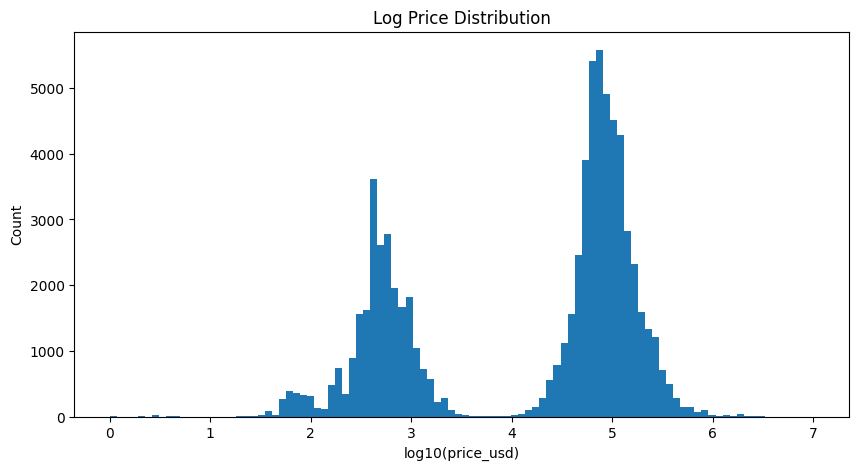

In [262]:
plt.figure(figsize=(10,5))
plt.hist(np.log10(df_cleaned["price_usd"] + 1), bins=100)
plt.xlabel("log10(price_usd)")
plt.ylabel("Count")
plt.title("Log Price Distribution")
plt.show()

In [263]:
df_cleaned["listing_type"] = "Unknown"

/var/folders/pn/2q111n451j10mgh135bwncf00000gn/T/ipykernel_40794/13968768.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["listing_type"] = "Unknown"


In [264]:
import re

RENT_MAX_PRICE = 2000
SALE_MIN_PRICE = 10000

def listing_type_scores(df):
    desc = df["description"].fillna("").str.lower()
    url = df["url"].fillna("").str.lower()

    rent_words = [
        "сдаётся", "сдается", "сдам", "сдаю", "аренда", "аренду",
        "посуточно", "помесячно",
        "ижарага", "ижара", "ijaraga", "ijara", "ijaraga beriladi",
        "topshiriladi", "арендага",
        "for rent", "to rent", "lease", "tenant"
    ]

    sale_words = [
        "продаётся", "продается", "продам", "продаю", "продажа",
        "сотилади", "sotiladi", "sotaman", "sotuv", "sotish",
        "ипотека", "рассрочка", "ipoteka",
        "for sale", "sell", "selling", "mortgage"
    ]


    rent_score = (
        sum(desc.str.contains(re.escape(w), regex=True, na=False).astype(int) for w in rent_words) * 3
        + sum(url.str.contains(re.escape(w), regex=True, na=False).astype(int) for w in rent_words)
    )

    sale_score = (
        sum(desc.str.contains(re.escape(w), regex=True, na=False).astype(int) for w in sale_words) * 3
        + sum(url.str.contains(re.escape(w), regex=True, na=False).astype(int) for w in sale_words)
    )

    return rent_score, sale_score


def classify_listings(df):
    rent_score, sale_score = listing_type_scores(df)
    price = df["price_usd"]

    conditions = [
        (sale_score > rent_score) & (price >= RENT_MAX_PRICE),
        (rent_score > sale_score) & (price < SALE_MIN_PRICE),
        (sale_score > rent_score) & (price < RENT_MAX_PRICE),
        (rent_score > sale_score) & (price >= SALE_MIN_PRICE),
        price >= SALE_MIN_PRICE,
    ]

    choices = ["Sale", "Rent", "Rent", "Sale", "Sale"]

    return np.select(conditions, choices, default="Rent")


df_cleaned["listing_type"] = classify_listings(df_cleaned)

# Sanity check
rent_score, sale_score = listing_type_scores(df_cleaned)

print(df_cleaned["listing_type"].value_counts())
print(f"\nAmbiguous both-hit rows: {((rent_score > 0) & (sale_score > 0)).sum()}")
print(f"No keyword rows: {((rent_score == 0) & (sale_score == 0)).sum()}")

/var/folders/pn/2q111n451j10mgh135bwncf00000gn/T/ipykernel_40794/2076063578.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["listing_type"] = classify_listings(df_cleaned)


listing_type
Sale    47038
Rent    25227
Name: count, dtype: int64

Ambiguous both-hit rows: 1409
No keyword rows: 29795


---

## `listing_id` malumot tozalash

In [265]:
print(f"listing_id dublikatlar soni: {len(df_cleaned)-len(df_cleaned['listing_id'].unique())}")

listing_id dublikatlar soni: 262


Qaysidir sabab orqali `listing_id` o'z ichiga dublikatlarni oladi.

In [266]:
print(f"Dublikatlar soni: {len(df_cleaned)}")
df_cleaned = df_cleaned.drop_duplicates(subset=['listing_id'])
print(f'Noyoblik soni dublikatlarni olib tashlangandam keyin: {len(df_cleaned)}')

Dublikatlar soni: 72265
Noyoblik soni dublikatlarni olib tashlangandam keyin: 72003


In [267]:
df_cleaned[df_cleaned.duplicated(subset='listing_id', keep=False)].sort_values(by = 'listing_id')

,listing_id,source,seller_type,housing_type,region,district,rooms,living_area_m2,kitchen_area_m2,total_area_m2,...,nearby,negotiable,price,currency,published_date,description,date_scraped,url,price_usd,listing_type


---

## `seller_type` tozalash jarayoni

In [268]:
df_cleaned['seller_type'].isna().sum()

np.int64(0)

seller_type column toza va hech qanday xatolar mavjud emas


---

## `housing_type`  malumot tozalash

In [269]:
df_cleaned['housing_type'].value_counts()

housing_type
new building               25615
resale                     21652
Новостройка                    5
новостройка                    3
От застройщика                 2
Новостройка.                   1
Кирпич                         1
Вторичка,кирпичный дом.        1
Name: count, dtype: int64

In [270]:
print(f"missing - {round(df_cleaned['housing_type'].isna().sum()/len(df_cleaned)*100, 2)}%")

missing - 34.34%


In [271]:
valid_housing_type = {
    'new building': 'new building',
    'resale': 'resale',
    'Новостройка': 'new building',
    'новостройка': 'new building',
    'Новостройка.': 'new building',
    'Вторичка,кирпичный дом.': 'new building'
}

def validate_housing_type(text):
    if pd.isna(text):
        return np.nan

    if text in valid_housing_type:
        return valid_housing_type[text]
    else:
        return np.nan

    return text

df_cleaned['housing_type'] = df_cleaned['housing_type'].apply(validate_housing_type)

In [272]:
df_cleaned['housing_type'].value_counts()

housing_type
new building    25625
resale          21652
Name: count, dtype: int64

---

## `region` malumot tozalash

In [273]:
df_cleaned['region'].value_counts()

region
Tashkent Region               62988
Samarkand Region               3208
Bukhara Region                 2882
Fergana Region                  741
Navoiy Region                   724
Khorezm Region                  344
Kashkadarya Region              325
Republic of Karakalpakstan      196
Surxondaryo Region              159
Andijan Region                  147
Jizzakh Region                  124
Sirdaryo Region                  94
Namangan Region                  71
Name: count, dtype: int64

In [274]:
df_cleaned['region'].isna().sum()

np.int64(0)

Region column toza. 

----


## `district` tozalash jarayoni

In [275]:
df_cleaned['district'].value_counts()

district
Mirzo-Ulugbek District    11464
Yunusabad District         8205
Yakkasaray District        7444
Mirabad District           6897
Yashnabad District         6721
                          ...  
Канлыкуль                     1
Иштыхан                       1
Турткуль                      1
Шерабад                       1
Гузалкент                     1
Name: count, Length: 170, dtype: int64

----


## `rooms` tozalash jarayoni

In [276]:
df_cleaned['rooms'].value_counts()

rooms
2.0      30156
3.0      22235
1.0      10199
4.0       7112
5.0       1653
6.0        312
7.0        120
8.0         74
9.0         31
10.0        15
12.0        14
11.0         5
60.0         5
50.0         5
25.0         4
100.0        3
400.0        3
51.0         3
70.0         3
22.0         3
47.0         2
30.0         2
64.0         2
14.0         2
20.0         2
52.0         2
500.0        2
26.0         2
67.0         1
72.0         1
94.0         1
65.0         1
35.0         1
215.0        1
66.0         1
45.0         1
78.0         1
23.0         1
24.0         1
150.0        1
21.0         1
222.0        1
270.0        1
86.0         1
90.0         1
49.0         1
16.0         1
450.0        1
133.0        1
15.0         1
19.0         1
13.0         1
37.0         1
125.0        1
123.0        1
165.0        1
53.0         1
350.0        1
56.0         1
111.0        1
Name: count, dtype: int64

In [277]:
df_cleaned_1 = df_cleaned[df_cleaned['rooms'] < 7].copy()

In [278]:
df_cleaned_1['rooms'].value_counts()

rooms
2.0    30156
3.0    22235
1.0    10199
4.0     7112
5.0     1653
6.0      312
Name: count, dtype: int64

Man 6 xonadan katta bo'lgan barcha elonlarni olib tashlashga qaror qildim.  
Kuzatuvlarga asoslanib shuni ayta olamanki. 6+ xonadonlar soni 500 ga yaqin va ularning ko'pchiligi xaqiqatga yaqin emas.

----

## `living_area_m2` tozalash jarayoni

In [279]:
print(f"missing: {round((df_cleaned_1['living_area_m2'].isna().sum()/len(df_cleaned_1['living_area_m2']))*100)}")

missing: 67


Raughly 68% of data is missing.

In [280]:
df_cleaned_1['living_area_m2'].describe()

count    23695.000000
mean        62.270666
std         46.721172
min          1.000000
25%         40.000000
50%         56.000000
75%         73.000000
max        999.000000
Name: living_area_m2, dtype: float64

Natijaga asoslanib shuni ayta olamizki `living_area_m2` judaham ishlatishga yaroqsiz.  
OLX `living_area_m2` ni optional qilib qoygan shu sabali `68 foiz` data bo'sh qoldirilgan.  
Judaham ko'b sotuvchilar taxminan to'ldirgan bo'lishlari mumkin.  
Katta extimollik bilan `living_area_m2` analysisda va predictive model uchun yaroqsis.

In [281]:
df_cleaned_1 = df_cleaned_1.drop(columns=['living_area_m2'])

---

## `kitchen_area_m2` Tozalash jarayoni

In [282]:
print(f"missing: {round((df_cleaned_1['kitchen_area_m2'].isna().sum()/len(df_cleaned_1['kitchen_area_m2']))*100)}")

missing: 77


In [283]:
df_cleaned_1['kitchen_area_m2'].describe()

count    16641.000000
mean        16.978344
std         42.718044
min          0.300000
25%          7.950000
50%         11.000000
75%         15.000000
max        999.000000
Name: kitchen_area_m2, dtype: float64

78% data to'ldirilmagan.  
Natijaga asoslanganda shu aniqki kiritilga raqamlar xaqiqatga yaqin emas.  


In [284]:
df_cleaned_1 = df_cleaned_1.drop(columns="kitchen_area_m2")

---

## `total_area_m2` Tozalash jarayoni

In [285]:
print(f"missing: {(df_cleaned_1['total_area_m2'].isna().sum()/len(df_cleaned_1['total_area_m2']))*100}")

missing: 0.01255808112520407


In [286]:
df_cleaned_1['total_area_m2'].describe()

count    71658.000000
mean        71.175919
std         44.199092
min          1.000000
25%         50.000000
50%         63.675000
75%         80.000000
max        999.000000
Name: total_area_m2, dtype: float64

In [287]:
df_cleaned_1=df_cleaned_1.dropna(subset=['total_area_m2'])

Q1 = df_cleaned_1['total_area_m2'].quantile(0.25)
Q3 = df_cleaned_1['total_area_m2'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Lower boundary: {lower}")
print(f"Upper boundary: {upper}")

Lower boundary: 5.0
Upper boundary: 125.0


In [288]:
df_cleaned_1.loc[df_cleaned_1['total_area_m2']>125.0, ["total_area_m2","price_usd"]]

,total_area_m2,price_usd
11,150.00,180000.0
20,240.00,800.0
42,600.00,14173.2
80,220.00,1500.0
89,128.00,165000.0
...,...,...
75523,170.00,300000.0
75599,145.34,299000.0
75671,136.00,165000.0
75704,140.00,120000.0


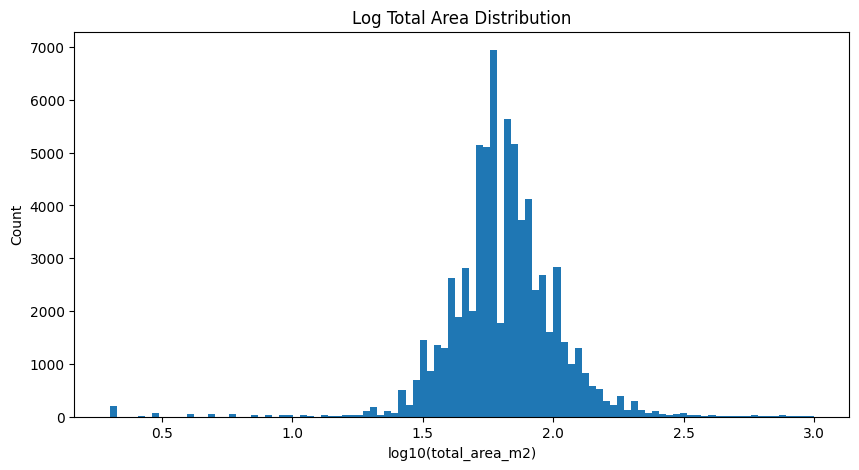

In [289]:
plt.figure(figsize=(10,5))
plt.hist(np.log10(df_cleaned_1['total_area_m2']+1), bins=100)
plt.xlabel("log10(total_area_m2)")
plt.ylabel("Count")
plt.title("Log Total Area Distribution")
plt.show()


In [290]:
lower = max(lower, 10)
upper = 400

df_cleaned_1 = df_cleaned_1[
    df_cleaned_1['total_area_m2'].between(lower, upper)
]

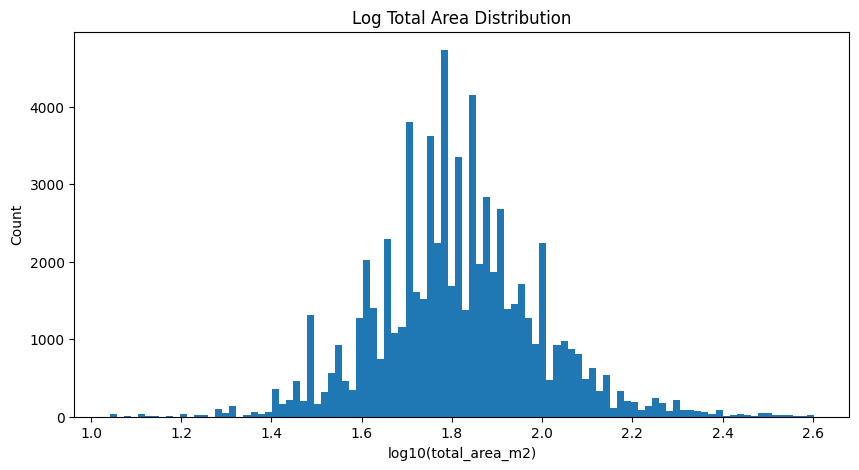

In [291]:
plt.figure(figsize=(10,5))
plt.hist(np.log10(df_cleaned_1['total_area_m2']+1), bins=100)
plt.xlabel("log10(total_area_m2)")
plt.ylabel("Count")
plt.title("Log Total Area Distribution")
plt.show()

In [292]:
print(len(df_cleaned_1))

70974


## `floor` & `total_floors` Tozalash jarayoni

In [293]:
df_cleaned_1['floor'].describe()

count    70972.000000
mean         4.866849
std          3.965342
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max        120.000000
Name: floor, dtype: float64

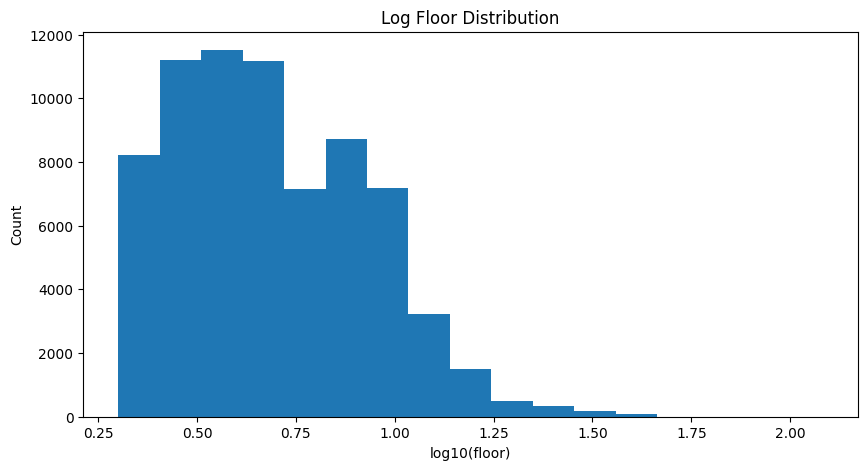

In [294]:
plt.figure(figsize=(10,5))
plt.hist(np.log10(df_cleaned_1['floor']+1),bins=17)
plt.xlabel("log10(floor)")
plt.ylabel("Count")
plt.title("Log Floor Distribution")
plt.show()

In [295]:
df_cleaned_1['floor'].value_counts()


floor
3.0      11518
2.0      11200
4.0      11162
1.0       8231
5.0       7149
6.0       4402
7.0       4326
8.0       4042
9.0       3151
10.0      1592
12.0       822
11.0       803
13.0       427
14.0       407
15.0       399
16.0       252
17.0       138
18.0       135
20.0        91
22.0        88
23.0        81
24.0        63
21.0        60
19.0        60
25.0        47
27.0        39
34.0        36
31.0        34
32.0        29
26.0        28
35.0        25
30.0        22
40.0        17
29.0        11
39.0        11
33.0        10
42.0         9
37.0         9
36.0         7
44.0         7
38.0         6
43.0         5
45.0         4
28.0         4
47.0         3
60.0         2
63.0         2
67.0         1
48.0         1
54.0         1
55.0         1
61.0         1
120.0        1
Name: count, dtype: int64

In [296]:
df_cleaned_1.loc[df_cleaned_1['floor'] > 30, ["price_usd","total_area_m2", "rooms", "floor", "total_floors","url"]]

,price_usd,total_area_m2,rooms,floor,total_floors,url
634,2200.0,120.0,3.0,34.0,51.0,https://www.olx.uz/d/obyavlenie/zhk-nest-one-s...
786,165000.0,65.0,2.0,31.0,48.0,https://www.olx.uz/d/obyavlenie/uspey-kupit-2-...
951,155000.0,59.0,2.0,37.0,48.0,https://www.olx.uz/d/obyavlenie/srochno-nedoro...
1433,280000.0,64.0,2.0,35.0,48.0,https://www.olx.uz/d/obyavlenie/prodaetsya-shi...
1510,3490.0,80.0,3.0,40.0,51.0,https://www.olx.uz/d/obyavlenie/nestone-a-blok...
...,...,...,...,...,...,...
73812,175000.0,65.0,2.0,40.0,48.0,https://www.olx.uz/d/obyavlenie/premialnaya-kv...
73939,225000.0,68.0,3.0,37.0,51.0,https://www.olx.uz/d/obyavlenie/tashkent-siti-...
74435,189000.0,39.0,1.0,31.0,51.0,https://www.olx.uz/d/obyavlenie/nest-one-proda...
74535,182000.0,40.0,2.0,31.0,51.0,https://www.olx.uz/d/obyavlenie/kvartira-nest-...


In [297]:
df_cleaned_1 = df_cleaned_1[df_cleaned_1['floor'] < 100]

In [298]:
df_cleaned_1["total_floors"].value_counts()

total_floors
4.0      16358
9.0      13456
5.0       9847
10.0      4734
7.0       3945
         ...  
74.0         1
60.0         1
650.0        1
46.0         1
270.0        1
Name: count, Length: 63, dtype: int64

In [299]:
df_cleaned_1 = df_cleaned_1[df_cleaned_1['total_floors'] < 100]

## `building_type` tozalash jarayoni 

In [300]:
df_cleaned_1["building_type"].value_counts()

building_type
brick                                                         31969
panel                                                         12920
monolith                                                       6935
block                                                          1259
Деревянный                                                      136
Панель                                                           20
панель-середина                                                  12
Панельный Планировка: Раздельный                                  5
.css-cgp8kk{border-top:1px solid #7F9799;margin-top:24px;}        5
кирпич                                                            4
Монолит                                                           3
монолит                                                           1
монолитная                                                        1
77-серия, имеется 6м балкон                                       1
кирпичный дом                     

In [301]:
df_cleaned_1.isna().sum()

listing_id            0
source                0
seller_type           0
housing_type      24246
region                0
district              0
rooms                 0
total_area_m2         0
floor                 0
total_floors          0
building_type     17689
layout            25382
build_year        49804
ceiling_height    45496
bathroom          19891
furnished             1
renovation        13279
commission            0
amenities         26186
nearby            23303
negotiable            0
price                 0
currency              0
published_date        0
description           0
date_scraped          0
url                   0
price_usd             0
listing_type          0
dtype: int64

In [248]:
def clean_building_type(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    if "css" in value:
        return np.nan

    if "кирп" in value or "brick" in value:
        return "brick"

    if "панел" in value or "panel" in value:
        return "panel"

    if "монолит" in value or "monolith" in value:
        return "monolith"

    if "блок" in value or "block" in value or "газоблок" in value:
        return "block"

    if "дерев" in value:
        return "wood"

    return np.nan

In [249]:
df_cleaned_1["building_type"] = df_cleaned_1["building_type"].apply(clean_building_type)

df_cleaned_1["building_type"].value_counts(dropna=False)

building_type
brick       31977
NaN         17695
panel       12958
monolith     6940
block        1260
wood          136
Name: count, dtype: int64

## `layout` tozalash jarayoni

In [302]:
df_cleaned_1['layout'].value_counts()

layout
separate                               35052
Смежно-раздельная                       3501
adjacent                                3210
studio                                  2361
Многоуровневая                           515
                                       ...  
Зал + кухня-студия, большие комнаты        1
Улучшенная, 2 та балкон                    1
1-в2 (одна спальня, кухня-гостиная)        1
См-Раздельная                              1
Французская                                1
Name: count, Length: 86, dtype: int64

In [303]:
def clean_layout(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    if value in ["-", ""]:
        return np.nan

    if "css" in value:
        return np.nan

    if "studio" in value or "студ" in value:
        return "studio"

    if "free layout" in value or "свобод" in value:
        return "free_layout"

    if "пентхаус" in value or "penthouse" in value:
        return "penthouse"

    if "многоуров" in value:
        return "multi_level"

    if "малосем" in value:
        return "small_family"

    if (
        "смежно" in value
        or "см-раз" in value
        or "см раз" in value
        or "сможно" in value
    ):
        return "adjacent_separate"

    if "смеж" in value:
        return "adjacent"

    if (
        "раздел" in value
        or "раздель" in value
        or "алоҳида" in value
        or "alohida" in value
        or value == "separate"
    ):
        return "separate"

    if "adjacent" in value:
        return "adjacent"

    return np.nan

df_cleaned_1["layout"] = df_cleaned_1["layout"].apply(clean_layout)

df_cleaned_1["layout"].value_counts(dropna=False)

layout
separate             35147
NaN                  25529
adjacent_separate     3515
adjacent              3283
studio                2366
multi_level            515
small_family           459
penthouse              150
free_layout              2
Name: count, dtype: int64